In [1]:
import pyedflib
import numpy as np
import mne
import matplotlib.pyplot as plt

from glob import glob
import os
import mne
import pandas as pd
import numpy as np

In [2]:
import struct
import datetime

def read_edf_header(file_path):
    """Lit seulement l'en-tête du fichier EDF sans charger les données"""
    with open(file_path, 'rb') as f:
        # Lire l'en-tête fixe (256 bytes)
        header = {}
        header['version'] = f.read(8).decode('ascii').strip()
        header['patient'] = f.read(80).decode('ascii').strip()
        header['recording'] = f.read(80).decode('ascii').strip()
        header['start_date'] = f.read(8).decode('ascii').strip()
        header['start_time'] = f.read(8).decode('ascii').strip()
        header['header_bytes'] = int(f.read(8).decode('ascii').strip())
        header['reserved'] = f.read(44).decode('ascii').strip()
        header['num_records'] = int(f.read(8).decode('ascii').strip())
        header['record_duration'] = float(f.read(8).decode('ascii').strip())
        header['num_signals'] = int(f.read(4).decode('ascii').strip())
        
        # Lire les informations de chaque canal
        ns = header['num_signals']
        
        labels = [f.read(16).decode('ascii').strip() for _ in range(ns)]
        transducer = [f.read(80).decode('ascii').strip() for _ in range(ns)]
        physical_dim = [f.read(8).decode('ascii').strip() for _ in range(ns)]
        physical_min = [float(f.read(8).decode('ascii').strip()) for _ in range(ns)]
        physical_max = [float(f.read(8).decode('ascii').strip()) for _ in range(ns)]
        digital_min = [int(f.read(8).decode('ascii').strip()) for _ in range(ns)]
        digital_max = [int(f.read(8).decode('ascii').strip()) for _ in range(ns)]
        prefiltering = [f.read(80).decode('ascii').strip() for _ in range(ns)]
        samples_per_record = [int(f.read(8).decode('ascii').strip()) for _ in range(ns)]
        reserved_signal = [f.read(32).decode('ascii').strip() for _ in range(ns)]
        
        channels = []
        for i in range(ns):
            channels.append({
                'label': labels[i],
                'transducer': transducer[i],
                'physical_dim': physical_dim[i],
                'physical_min': physical_min[i],
                'physical_max': physical_max[i],
                'digital_min': digital_min[i],
                'digital_max': digital_max[i],
                'prefiltering': prefiltering[i],
                'samples_per_record': samples_per_record[i],
                'sample_rate': samples_per_record[i] / header['record_duration']
            })
        
        return header, channels

# Chemin vers votre fichier
file_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\data_test\\C1_012_PSG1.edf"


print("Lecture de l'en-tête du fichier EDF...")
header, channels = read_edf_header(file_path)

# Informations générales
print("=" * 60)
print("INFORMATIONS GÉNÉRALES DU FICHIER")
print("=" * 60)
print(f"Version: {header['version']}")
print(f"Patient: {header['patient']}")
print(f"Enregistrement: {header['recording']}")
print(f"Date de début: {header['start_date']} {header['start_time']}")
print(f"Nombre de signaux: {header['num_signals']}")
print(f"Nombre d'enregistrements: {header['num_records']}")
print(f"Durée d'un enregistrement: {header['record_duration']} secondes")
total_duration = header['num_records'] * header['record_duration']
print(f"Durée totale: {total_duration:.2f} secondes ({total_duration/3600:.2f} heures)")
print()

# Liste des canaux avec leurs caractéristiques
print("=" * 60)
print("LISTE DES CANAUX ENREGISTRÉS")
print("=" * 60)

for i, ch in enumerate(channels):
    print(f"\nCanal {i+1}: {ch['label']}")
    print(f"  - Fréquence d'échantillonnage: {ch['sample_rate']:.1f} Hz")
    print(f"  - Unité physique: {ch['physical_dim']}")
    print(f"  - Min/Max physique: {ch['physical_min']} / {ch['physical_max']}")
    print(f"  - Transducteur: {ch['transducer']}")
    if ch['prefiltering']:
        print(f"  - Pré-filtrage: {ch['prefiltering']}")

# Catégorisation des canaux
print("\n" + "=" * 60)
print("CATÉGORISATION DES SIGNAUX")
print("=" * 60)

eeg_channels = []
eog_channels = []
emg_channels = []
ecg_channels = []
other_channels = []

for ch in channels:
    label = ch['label'].upper()
    
    if any(x in label for x in ['EEG', 'C3', 'C4', 'F3', 'F4', 'O1', 'O2', 'FP', 'CZ', 'PZ', 'FZ', 'T3', 'T4', 'T5', 'T6', 'A1', 'A2']):
        eeg_channels.append(ch['label'])
    elif any(x in label for x in ['EOG', 'E1', 'E2', 'LOC', 'ROC']):
        eog_channels.append(ch['label'])
    elif any(x in label for x in ['EMG', 'CHIN', 'LEG', 'TIBIAL']):
        emg_channels.append(ch['label'])
    elif any(x in label for x in ['ECG', 'EKG', 'HEART']):
        ecg_channels.append(ch['label'])
    else:
        other_channels.append(ch['label'])

print(f"\nEEG ({len(eeg_channels)} canaux):")
for ch in eeg_channels:
    print(f"  - {ch}")

print(f"\nEOG ({len(eog_channels)} canaux):")
for ch in eog_channels:
    print(f"  - {ch}")

print(f"\nEMG ({len(emg_channels)} canaux):")
for ch in emg_channels:
    print(f"  - {ch}")

print(f"\nECG ({len(ecg_channels)} canaux):")
for ch in ecg_channels:
    print(f"  - {ch}")

print(f"\nAutres ({len(other_channels)} canaux):")
for ch in other_channels:
    print(f"  - {ch}")

print("\n" + "=" * 60)
print("Analyse terminée!")
print("=" * 60)

Lecture de l'en-tête du fichier EDF...
INFORMATIONS GÉNÉRALES DU FICHIER
Version: 0
Patient: X X 30-DEC-1899 X_X
Enregistrement: Startdate 15-OCT-2021 X X X
Date de début: 15.10.21 22.09.14
Nombre de signaux: 74
Nombre d'enregistrements: 32879
Durée d'un enregistrement: 1.0 secondes
Durée totale: 32879.00 secondes (9.13 heures)

LISTE DES CANAUX ENREGISTRÉS

Canal 1: F3
  - Fréquence d'échantillonnage: 256.0 Hz
  - Unité physique: uV
  - Min/Max physique: -1000.0 / 1000.0
  - Transducteur: EEG F3

Canal 2: F4
  - Fréquence d'échantillonnage: 256.0 Hz
  - Unité physique: uV
  - Min/Max physique: -1000.0 / 1000.0
  - Transducteur: EEG F4

Canal 3: T7/T3
  - Fréquence d'échantillonnage: 256.0 Hz
  - Unité physique: uV
  - Min/Max physique: -1000.0 / 1000.0
  - Transducteur: EEG T7/T3

Canal 4: C3
  - Fréquence d'échantillonnage: 256.0 Hz
  - Unité physique: uV
  - Min/Max physique: -1000.0 / 1000.0
  - Transducteur: EEG C3

Canal 5: Cz
  - Fréquence d'échantillonnage: 256.0 Hz
  - Unité p

In [3]:
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Version PyTorch: {torch.__version__}")

CUDA disponible: True
Version PyTorch: 2.6.0+cu126


Idee preprocess : 
- Drop le canal si trop de valeurs aberrante et le faire pour chaque personne 
- Crop les valeurs aberantes 

In [ ]:
def preprocess(raw):
    mne.set_bipolar_reference(
        raw, "EMG 1", "EMG 2", ch_name = "EMG", copy = False
        )
    raw.set_channel_types({'EMG':'emg'})
    mne.set_eeg_reference(raw, ["A2"], copy = False)
    raw.drop_channels(['A2'])
    sfreq = raw.info["sfreq"] 
    raw.resample(128, npad="auto")
    raw.notch_filter([50]) 
    raw.filter(l_freq=0.3, h_freq=35, n_jobs=-1)
    return raw, sfreq
#ampl > 500 a enlever eeg
    
def plotter(
    raw,
    eeg_channels=['Fp1', 'C3', 'O1', 'C4'],
    eog_channels=['EOG G', 'EOG D'],
    emg_channels=['EMG'],             # peut être ['EMG', 'EMG 1', 'EMG 2'] etc.
    ecg_channels=['ECG'],             # peut être ['ECG', 'ECG1', ...]
    start=0,
    stop=30
):
    plt.close('all')
    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
    fig.suptitle('Enregistrement Polysomnographique - Prétraité',
                 fontsize=16, fontweight='bold')

    start_samp = raw.time_as_index(start)[0]
    stop_samp  = raw.time_as_index(stop)[0]
    times = raw.times[start_samp:stop_samp]

    def _plot_group(ax, ch_list, ylabel, title):
        plotted = False
        for ch in ch_list:
            if ch in raw.ch_names:
                idx = raw.ch_names.index(ch)
                data = raw.get_data(picks=idx, start=start_samp, stop=stop_samp)[0]
                ax.plot(times, data * 1e6, label=ch, linewidth=0.8)
                plotted = True
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_title(title, loc='left', fontsize=11)
        if plotted:
            ax.legend(loc='upper right', fontsize=9)
        else:
            ax.text(0.01, 0.8, "Aucun canal trouvé", transform=ax.transAxes, fontsize=9)

    # 1) EEG
    _plot_group(axes[0], eeg_channels, 'EEG (µV)', 'Électroencéphalogramme (EEG)')

    # 2) EOG
    _plot_group(axes[1], eog_channels, 'EOG (µV)', 'Électro-oculogramme (EOG)')

    # 3) EMG (comme EEG/EOG)
    _plot_group(axes[2], emg_channels, 'EMG (µV)', 'Électromyogramme (EMG)')

    # 4) ECG (comme EEG/EOG)
    _plot_group(axes[3], ecg_channels, 'ECG (µV)', 'Électrocardiogramme (ECG)')

    axes[3].set_xlabel('Temps (s)', fontweight='bold')
    plt.tight_layout()
    plt.show()

Extracting EDF parameters from C:\Users\gabri\Desktop\stage_sommeil\algo\data_test\C1_012_PSG1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8417023  =      0.000 ... 32878.996 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=8417024
    Range : 0 ... 8417023 =      0.000 ... 32878.996 secs
Ready.
Added the following bipolar channels:
EMG
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upp

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Overwriting existing file.


[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    3.4s remaining:    3.4s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    3.5s finished
C:\Users\gabri\AppData\Local\Temp\ipykernel_4120\189329630.py:19: RuntimeWarning: This filename (C:\Users\gabri\Desktop\stage_sommeil\algo\data_test\gab_C1_012_PSG1.edf_preproc.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(this_savepath, overwrite=True)


Writing C:\Users\gabri\Desktop\stage_sommeil\algo\data_test\gab_C1_012_PSG1.edf_preproc.fif
Overwriting existing file.
Closing C:\Users\gabri\Desktop\stage_sommeil\algo\data_test\gab_C1_012_PSG1.edf_preproc.fif
[done]
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\gabri\AppData\Local\Temp\ipykernel_4120\189329630.py:21: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=64)
c:\Users\gabri\anaconda3\envs\gab\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


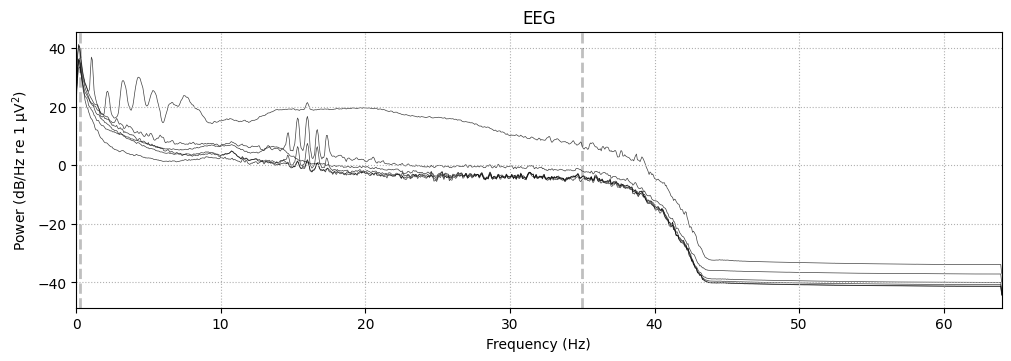

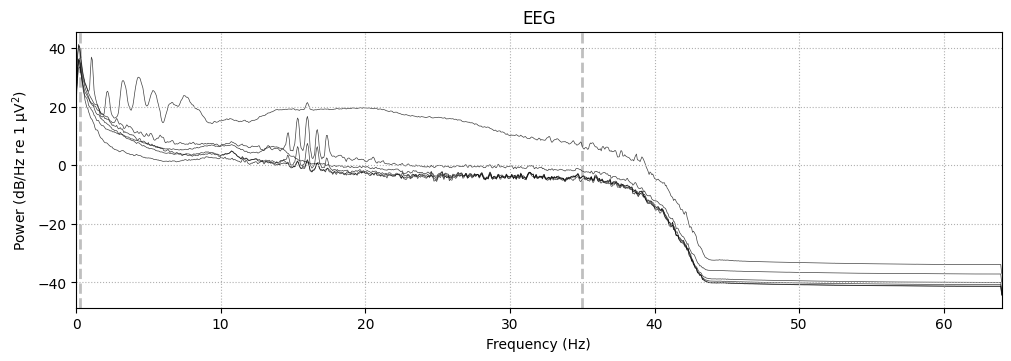

In [5]:
files = glob(os.path.join("C:\\Users\\gabri\\Desktop","stage_sommeil\\algo\\data_test\\C1_012_PSG1.edf"))
CHANNEL_GROUPS = {
    "EEG": ["Fp1", "C3", "O1","C4"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG 1", "EMG 2"],          
    "ECG": ["ECG"],
    "REF": ["A2"],                      
}

# liste plate pour include=
CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})
for i, file in enumerate(files) :
    sub_id = file.split('data_test\\')[-1]

    this_savepath = os.path.join("C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\data_test", f"gab_{sub_id}_preproc.fif")

    raw = mne.io.read_raw_edf(file, include = CHANNEL_OI, preload = True)
    raw, sfreq = preprocess(raw)
    raw.save(this_savepath, overwrite=True)

raw.plot_psd(fmax=64)

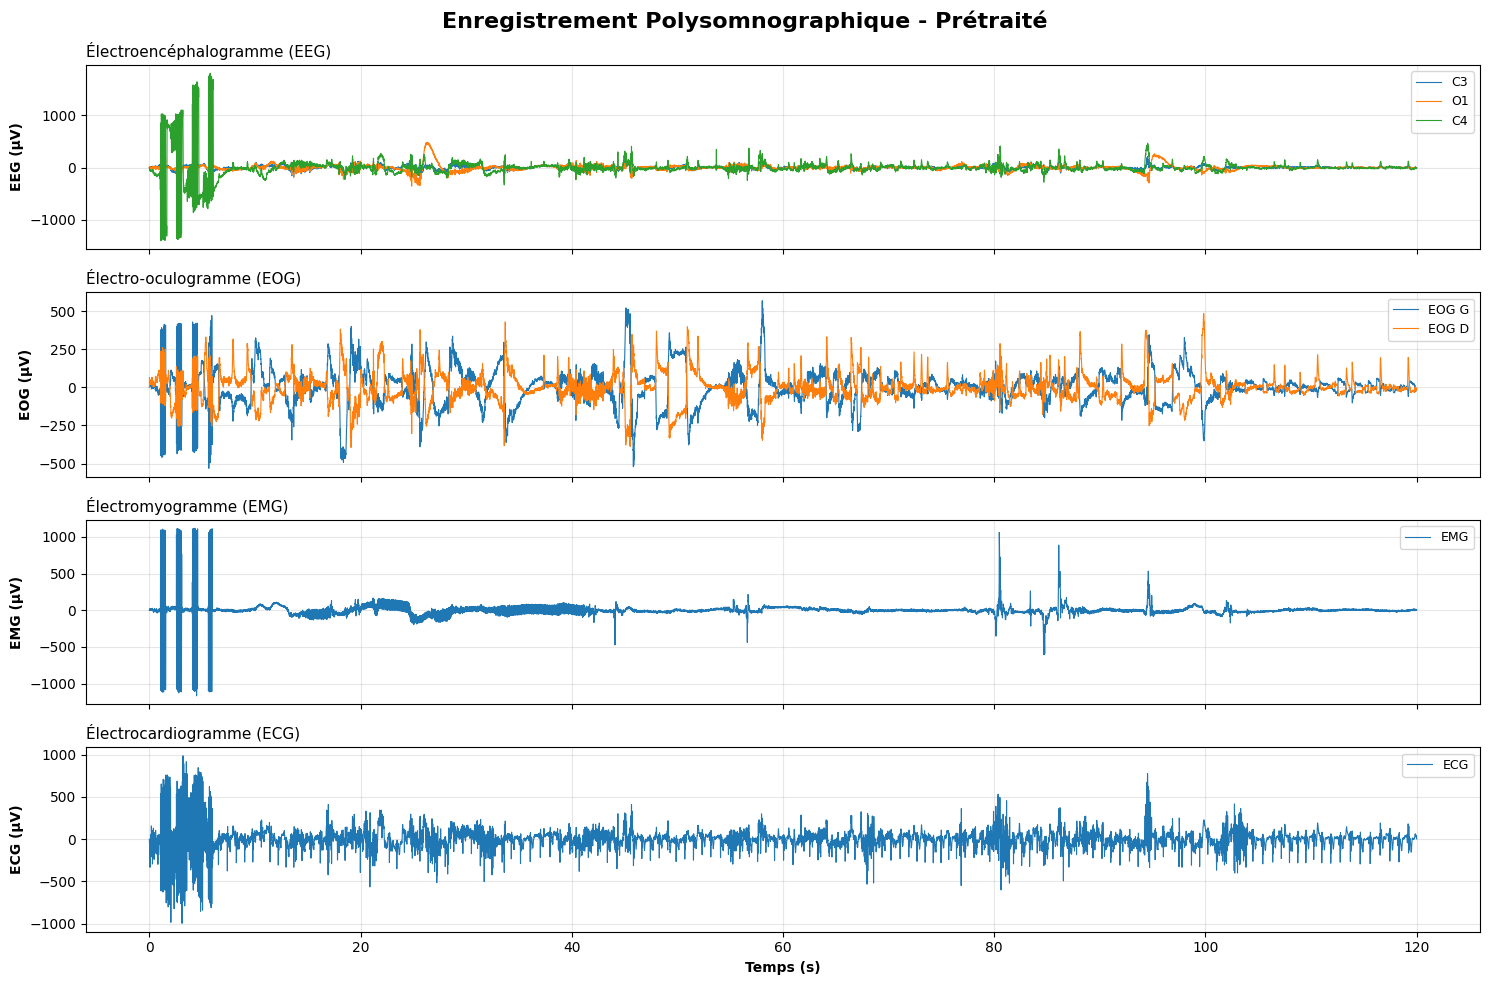

In [10]:
plotter(raw, eeg_channels=CHANNEL_GROUPS["EEG"],
        eog_channels=CHANNEL_GROUPS["EOG"], 
        emg_channels=["EMG"],
        ecg_channels=CHANNEL_GROUPS["ECG"],
        start=0,
        stop=120
)


In [7]:
bad_channels, scores = mne.preprocessing.find_bad_channels_lof(
    raw, 
    n_neighbors=5, 
    picks=None, 
    metric='euclidean', 
    threshold=1.3, 
    return_scores=True,  # True pour avoir les scores aussi
    verbose=None
)

print(f"Canaux suspects : {bad_channels}")
print(f"Scores : {scores}")

print(raw.info["bads"])


LOF: Detected bad channel(s): []
Canaux suspects : []
Scores : [-1.01329285 -0.98193052 -1.00874785 -1.00259074 -1.01240141 -0.98193052]
[]


In [8]:
#ssp_projectors = raw.info["projs"]
#raw.del_proj()

In [9]:
def txt_to_good_csv(txt_file = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\data_test\\PSG4_Hypnogram_Export_C1_012_PSG1.txt" , csv_file = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\data_test\\PSG4_Hypnogram_Export_C1_012_PSG1.csv"):
    STAGE_TO_NUMBER = {
        'W': 0,
        '1': 1,
        '2': 2,
        '3': 3,
        '4': 3,
        'R': 4
    }
    STAGE_NAMES = {
        0: "Wake",
        1: "Stage 1",
        2: "Stage 2",
        3: "Stage 3",
        4: "REM"
    }
    stages_30s = np.loadtxt(txt_file, dtype=str)
    # Répéter chaque stage 6 fois (pour 6 epochs de 5s)
    stages_5s = np.repeat(stages_30s, 6)
    n_epochs = len(stages_5s)
    starts = np.arange(0, n_epochs * 5, 5)
    stops = starts + 5
    df = pd.DataFrame({
    'Start': starts,
    'Stop': stops,
    'StageName': [STAGE_NAMES.get(STAGE_TO_NUMBER.get(s, -1), "Unknown") for s in stages_5s],
    'StageNumber': [STAGE_TO_NUMBER.get(s, -1) for s in stages_5s],
    'EmbeddingNumber': np.arange(n_epochs)
    })

    df.to_csv(csv_file, index=False)


txt_to_good_csv()

A faire :
- gerer artefact / demander arthur si mon preprocess est ok
- fasse un mapping des canaux que j'ai vers ceux de sleep fm
- commencer par des données ou je suis sur que les canaux existe avant de les enlever
- generer des embedding
- sortir les annotations les y
- essayer de fine tune un petit modele 
- Voir comment faire tourner le programme en ligne sur one drive pour pas tout telecharger
- Essayer plus de canaux
- predire les maladies
